# Lecture 6: Three Dimensional Systems and the Lorenz Equations

Any questions or comments to *hannah.christensen@physics.ox.ac.uk*

Book of the course: Nonlinear Dynamics and Chaos, by Steven Strogatz 

Also recommended: \
Deterministic Nonperiodic Flow, Ed Lorenz, Journal of the Atmospheric Sciences, 1963 \
Chaos, by James Gleick

## Chaos

The double pendulum

Video source: https://www.youtube.com/watch?v=-gnLMiXAGvE
    

## The Lorenz (1963) Equations

In this lecture we introduce a simple non-linear model of Rayleigh-Bénard convection, that led to the discovery of chaos by Ed Lorenz in 1963.

Video source: https://www.youtube.com/watch?v=OM0l2YPVMf8


The Lorenz equations were originally derived by Saltzman (1962) as a ‘minimalist’ model of Rayleigh-Bénard convection

$$ \begin{eqnarray}
\dot{x} & = & \sigma (y - x) \\
\dot{y} & = & r x - y - xz \\
\dot{z} & = & xy - bz
\end{eqnarray} $$

$ $where $\sigma$ (''Prandtl number''), $r$ (''Rayleigh number'') and $b$ (the aspect ratio of the box) are parameters $(> 0)$.

$x$ is proportional to the strength of the convective motion, $y$ is proportional to the temperature difference between the ascending and descending currents, and $z$ is proportional to the distortion of the vertical temperature profile from linearity.

#### Simple properties

- Nonlinear

- Invariant under $(x,y) \rightarrow (-x,-y)$. So if ( x(t), y(t), z(t) ) is a solution, so too is ( -x(t), -y(t), z(t) ).


These equations also arise in studies of convection and instability in planetary atmospheres, models of lasers and dynamos etc. Willem Malkus also devised a water-wheel demonstration...

Youtube: https://www.youtube.com/watch?v=7A_rl-DAmUE



<div>
<img src="figures/fig6_0a.png" width="800"/>
</div>



This simple-looking deterministic system turns out to have interesting erratic dynamics!



### Volume contraction

For a general 3D system, $\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x})$, how does a volume element evolve in time?



<div>
<img src="figures/6_volume.png" width="600"/>
</div>

Consider a small volume element at time t, V(t), bounded by surface S(t). What is its new volume at time t+dt, V(t+dt)?

We can consider the volume swept out by a small element of the surface, dA. Since $\mathbf{f}$ is the instantaneous velocity, and if $\mathbf{n}$ is the normal to S(t), then the volume swept out is $(\mathbf{f} \cdot \mathbf{n}) dt dA$

Integrating over the surface gives the total volume change:

$ \Delta V = \int (\mathbf{f} \cdot \mathbf{n}) dt dA $

$ = \int (\nabla \cdot \mathbf{f} ) dt dV $

Where the last step uses the divergence theorem.

We therefore have it that

$ \dot{V} = \int (\nabla \cdot \mathbf{f} ) dV $


For the Lorenz system, $\nabla \cdot \mathbf{f} = - \sigma -1 -b < 0$

Thus $V(t) = V(0) e^{-(\sigma +1 +b)t}$. i.e. volumes in phase space contract. The system is dissipative.

### Fixed Points and their stability

Setting $\dot{x} = \dot{y} = \dot{z} = 0$, we find fixed points at:

$\bullet$ Origin, $\; (0,0,0)$ 

$\bullet \, C^+, \; (\sqrt{b(r−1)},􏰃 \sqrt{b(r−1)}, r−1);$ 

$\bullet \, C^-, \;(-\sqrt{b(r−1)},􏰃 -\sqrt{b(r−1)}, r−1);$

The fixed points at $C^+$ and $C^-$ only exist for $r>1$.

The origin is stable for $r<1$ and unstable for $r > 1$ (see problem set 1). Thus at $r=1$ the origin loses stability through a *supercritical pitchfork* bifurcation

The stability of $C^+$ and $C^-$ is harder to establish, and involves solving a cubic equation.

The solution is that $C^+$ and $C^-$ are stable for 

$$ 1 < r < r_H = {\sigma (\sigma + b + 3) \over \sigma - b - 1} $$

$ $assuming that $\sigma - b - 1 > 0$.




<div>
<img src="figures/fig6_1_1.png" width="800"/>
</div>

So a *subcritical Hopf bifurcation* must occur at $r=r_H$



What happens after the subcritical Hopf bifurcation?

We can find a large bounding ellipse to demonstrate that trajectories do not fly off to infinity.

We know there is no stable fixed point. Lorenz argued (see Strogatz) that there can be no stable limit cycle. Therefore, trajectories must fly off to a *distant strange attractor*.



## Chaos on a Strange Attractor

$ $Lorenz considered the case $\sigma = 10, b = 8/3, r = 28$ with $(x_0,y_0,z_0) = (0,1,0)$.

$ $NB $r_H = \sigma (\sigma + b + 3)/(\sigma - b - 1) \simeq 24.74$, hence $r > r_H$.

For these parameter values, the system is drawn towards  *strange attractor* with many beautiful properties.

The following python script allows you to explore the Lorenz system.\
$\bullet$ What happens if we change the initial conditons? \
$\bullet$ How do trajectories in $x$ and $z$ compare to $y$? \
$\bullet$ How do the solutions change if we change the parameter values? - consider values either side of the super- and sub-critical Hopf bifurcations.\
$\bullet$ Is there anything predictable about the trajectory?


(2000, 3)


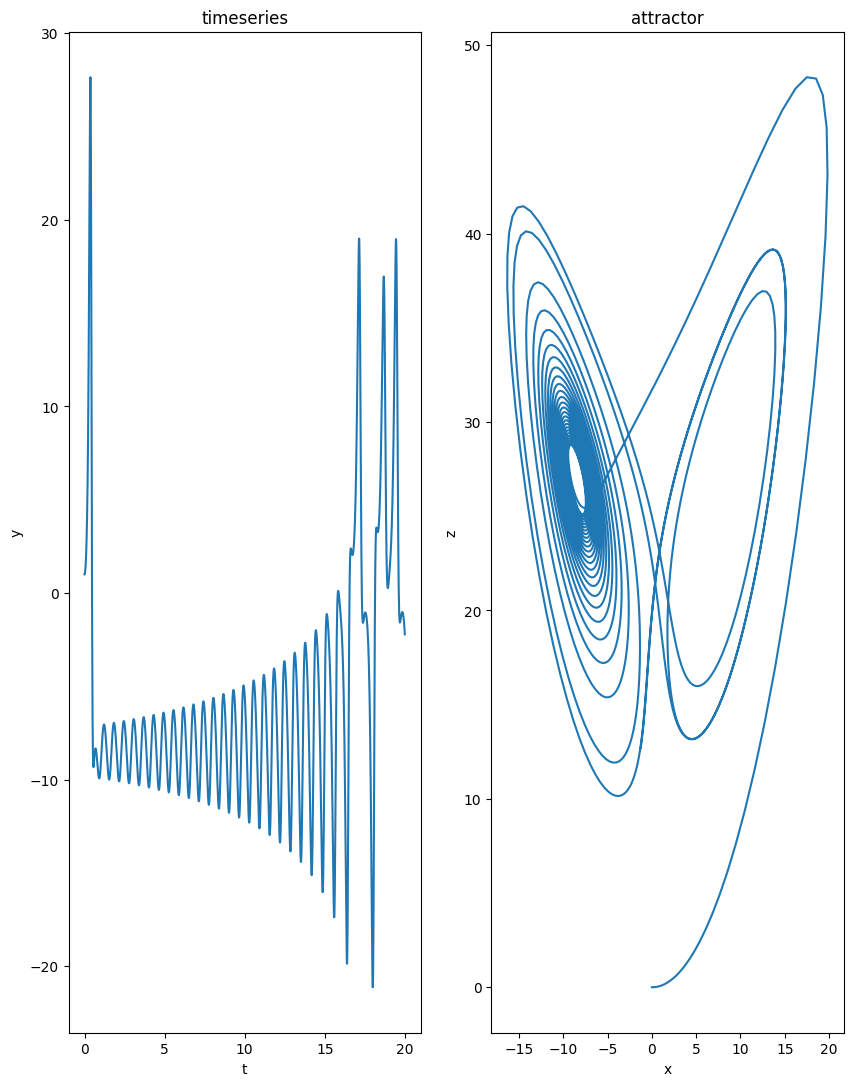

In [26]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import matplotlib as mpl

# define lorenz parameters. L63 values shown
sig = 10  # (10)
b = 8/3   # (8/3)
r = 28    # (28)

def lorenz(v, t):
    x = v[0]; y = v[1]; z = v[2]
    
    dxdt = sig*(y - x)
    dydt = r*x - y - x*z
    dzdt = x*y - b*z
    
    ddt = [dxdt, dydt, dzdt]
    return ddt

v0 = [0, 1, 0]

t = np.arange(0,20,0.01)
v = odeint(lorenz, v0, t)
print(v.shape)

ax1 = plt.subplot(1,2,1)
plt.plot(t,v[:,1])
plt.xlabel('t'); plt.ylabel('y'); plt.title('timeseries')

ax2 = plt.subplot(1,2,2)
ax2.plot(v[:,0],v[:,2])
plt.xlabel('x'); plt.ylabel('z'); plt.title('attractor');

mpl.rcParams['figure.figsize'] = [30, 40]


$\bullet$ there are no stable fixed points $r > r_H$, and any limit cycles for $r > r_H$ are unstable. The trajectories for $r > r_H$ are therefore continually being repelled from one unstable object to another.

<div>
<img src="figures/fig6_2_1.png" width="800"/>
</div>

$\bullet$ After an initial transient adjustment, the solution settles into an irregular oscillation that persists as $t \rightarrow \infty$ but never repeats exactly — the motion is *aperiodic*.

$\bullet$ Lorenz showed that the trajectories are nevertheless confined to a bounded region

$\bullet$ The trajectory in phase space assumes the famous 'butterfly wing' pattern (r = 28, σ = 10, b = 8/3):

<div>
<img src="figures/fig6_2_2.png" width="800"/>
</div>

$\bullet$ The trajectory appears to cross itself repeatedly, but that’s just an artifact of projecting the 3-
dimensional trajectory onto a 2-dimensional plane. In 3-D *no crossings occur!*

$\bullet$ The number of circuits made on either side varies unpredictably from one cycle to the next. The sequence of the number of circuits in each lobe has many of the characteristics of a random sequence!


$\bullet$ When the trajectory is viewed in all 3 dimensions, it appears to settle onto a thin set that looks like a pair of butterfly wings. We call this attractor a *strange attractor* and it can be shown schematically as...

<div>
<img src="figures/fig6_2_3.png" width="800"/>
</div>

This attractor must have zero volume in phase space because all volumes contract. 

What is the geometric structure of the strange attractor?

$\bullet$ The uniqueness theorem means that trajectories *cannot cross* or merge, hence the two surfaces of the strange attractor can only *appear* to merge.

$\bullet$ Lorenz concluded that “there is an infinite complex of surfaces” where they *appear* to merge. Today this “infinite complex of surfaces” would be called a fractal.

$\bullet$ A *fractal* is a set of points with zero volume but infinite surface area. We return to fractals in Lecture 8.

The python script below (courtesy Nick Leach) plots the Lorenz attractor in 3D - use your mouse to rotate the attractor and zoom in on interesting regions. 

In [33]:
## Thanks to Nick Leach for the visualisation

import numpy as np
import scipy as sp
import scipy.signal
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sn
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import plotly
import plotly.graph_objects as go

## Specify model parameters:
sigma = 10
rho = 28
beta = 8/3

## Specify integration time and timestep:
dt = 0.01
int_time = 100
time = np.arange( 0 , int_time , dt )

## Create required coordinate arrays
x = np.empty( time.size )
y = np.empty( time.size )
z = np.empty( time.size )

## Specify initial conditions
x[0] , y[0] , z[0] = ( 1 , 1 , 1)

## integrate the model (Euler's method):

for i in np.arange( 1 , time.size ):
    x[i] = x[i-1] + dt * ( sigma * ( y[i-1] - x[i-1] ) )
    y[i] = y[i-1] + dt * ( x[i-1] * ( rho - z[i-1] ) - y[i-1] )
    z[i] = z[i-1] + dt * ( -beta * z[i-1] + x[i-1] * y[i-1] )
    
## note here you could use scipy's odeint instead:
# def lorenz(X, t):
#     x, y, z = X  # Unpack the state vector
#     return sigma * (y - x), x * (rho - z) - y, x * y - beta * z  # Derivatives
# X0 = [1.0, 1.0, 1.0]
# Xs = sp.integrate.odeint(lorenz, X0, time)

## Calculate (local) lyapunov exponents at each point for coloring
# function to compute local lyapunov exponent as maximum eigenvalue of Jacobian at (x,y,z)
def local_lyapunov_max(x , y , z):
    J = np.array([ [ -sigma , sigma , 0 ],[ rho - z , -1 , -x ],[ y , x , -beta ] ])
    eig_val = np.linalg.eig(J)[0]
    return np.real(eig_val).max()

# calculate the eigenvalues at each point on the attractor
lyapunov_exp = np.array([local_lyapunov_max(x[i],y[i],z[i]) for i in np.arange(time.size)])
print(lyapunov_exp[0:100])


[11.47126937 11.47076008 11.46621031 11.45714684 11.44281776 11.42217652
 11.39383739 11.35600261 11.30635678 11.24191899 11.15883615 11.05208965
 10.91506707 10.73891178 10.51148146 10.21555817  9.8254625   9.29971938
  8.56150347  7.42252908  4.32406238  4.28425411  4.23440233  4.17223848
  4.09503137  3.99952013  3.88185156  3.7375311   3.56140129  3.34766759
  3.08999814  2.78173025  2.41621861  1.98735237  1.49024316  0.92203398
  0.28270097 -0.42436854 -1.19228497 -2.01122359 -2.86943329 -3.75358161
 -4.37494776 -2.63762691 -1.06599613  0.16736307  0.8883343   0.95618943
  0.18450531 -2.07114308 -3.25380096 -1.82072476 -1.13693015 -0.76006513
 -0.55286062 -0.45279618 -0.4252358  -0.44875289 -0.50907652 -0.59611881
 -0.70234292 -0.82180282 -0.94955522 -1.08129169 -1.21310589 -1.34134438
 -1.46250815 -1.57318414 -1.66999561 -1.74956972 -1.80853251 -1.84355689
 -1.8515057  -1.82972157 -1.77649326 -1.69164452 -1.57704518 -1.43673598
 -1.27645571 -1.1026865  -0.92162274 -0.73845029 -0

In [34]:
## Thanks to Nick Leach for the visualisation

fig = go.Figure( data=[ go.Scatter3d(
    x=x,
    y=y,
    z=z,
    mode='lines',
    line=dict(
        colorscale='magma',
        color=lyapunov_exp
        )
    ) ] )

fig.update_layout(scene = dict(
                    xaxis = dict(
                         showbackground=False,
                         zerolinecolor="grey",),
                    yaxis = dict(
                        showbackground=False,
                        zerolinecolor="grey"),
                    zaxis = dict(
                        showbackground=False,
                        zerolinecolor="grey",),),
                    width=700,
                    margin=dict(
                    r=10, l=10,
                    b=10, t=10)
                  )

fig.show()

### Exponential divergence of nearby trajectories

The motion on the attractor exhibits *sensitive dependence on initial conditions*. Two trajectories starting very close together will rapidly diverge from each other, and thereafter have totally different futures.

The practical implication is that long-term prediction becomes impossible in a system like this, where small uncertainties are amplified enormously fast.



Consider an initial condition on the attractor. Suppose ${\bf x}(t)$ is a point on the attractor at time $t$, and consider a nearby point, say ${\bf x}(t) + {\bf \delta}(t)$, where ${\bf \delta}$ is a tiny separation vector of initial length $||\delta_0|| = 10^{-15}$, say

<div>
<img src="figures/fig6_2_4.png" width="800"/>
</div>
 
In the following python script, explore sensitive dependence on initial conditions by changing $\delta$. How does changing the Lorenz parameter values impact this property?

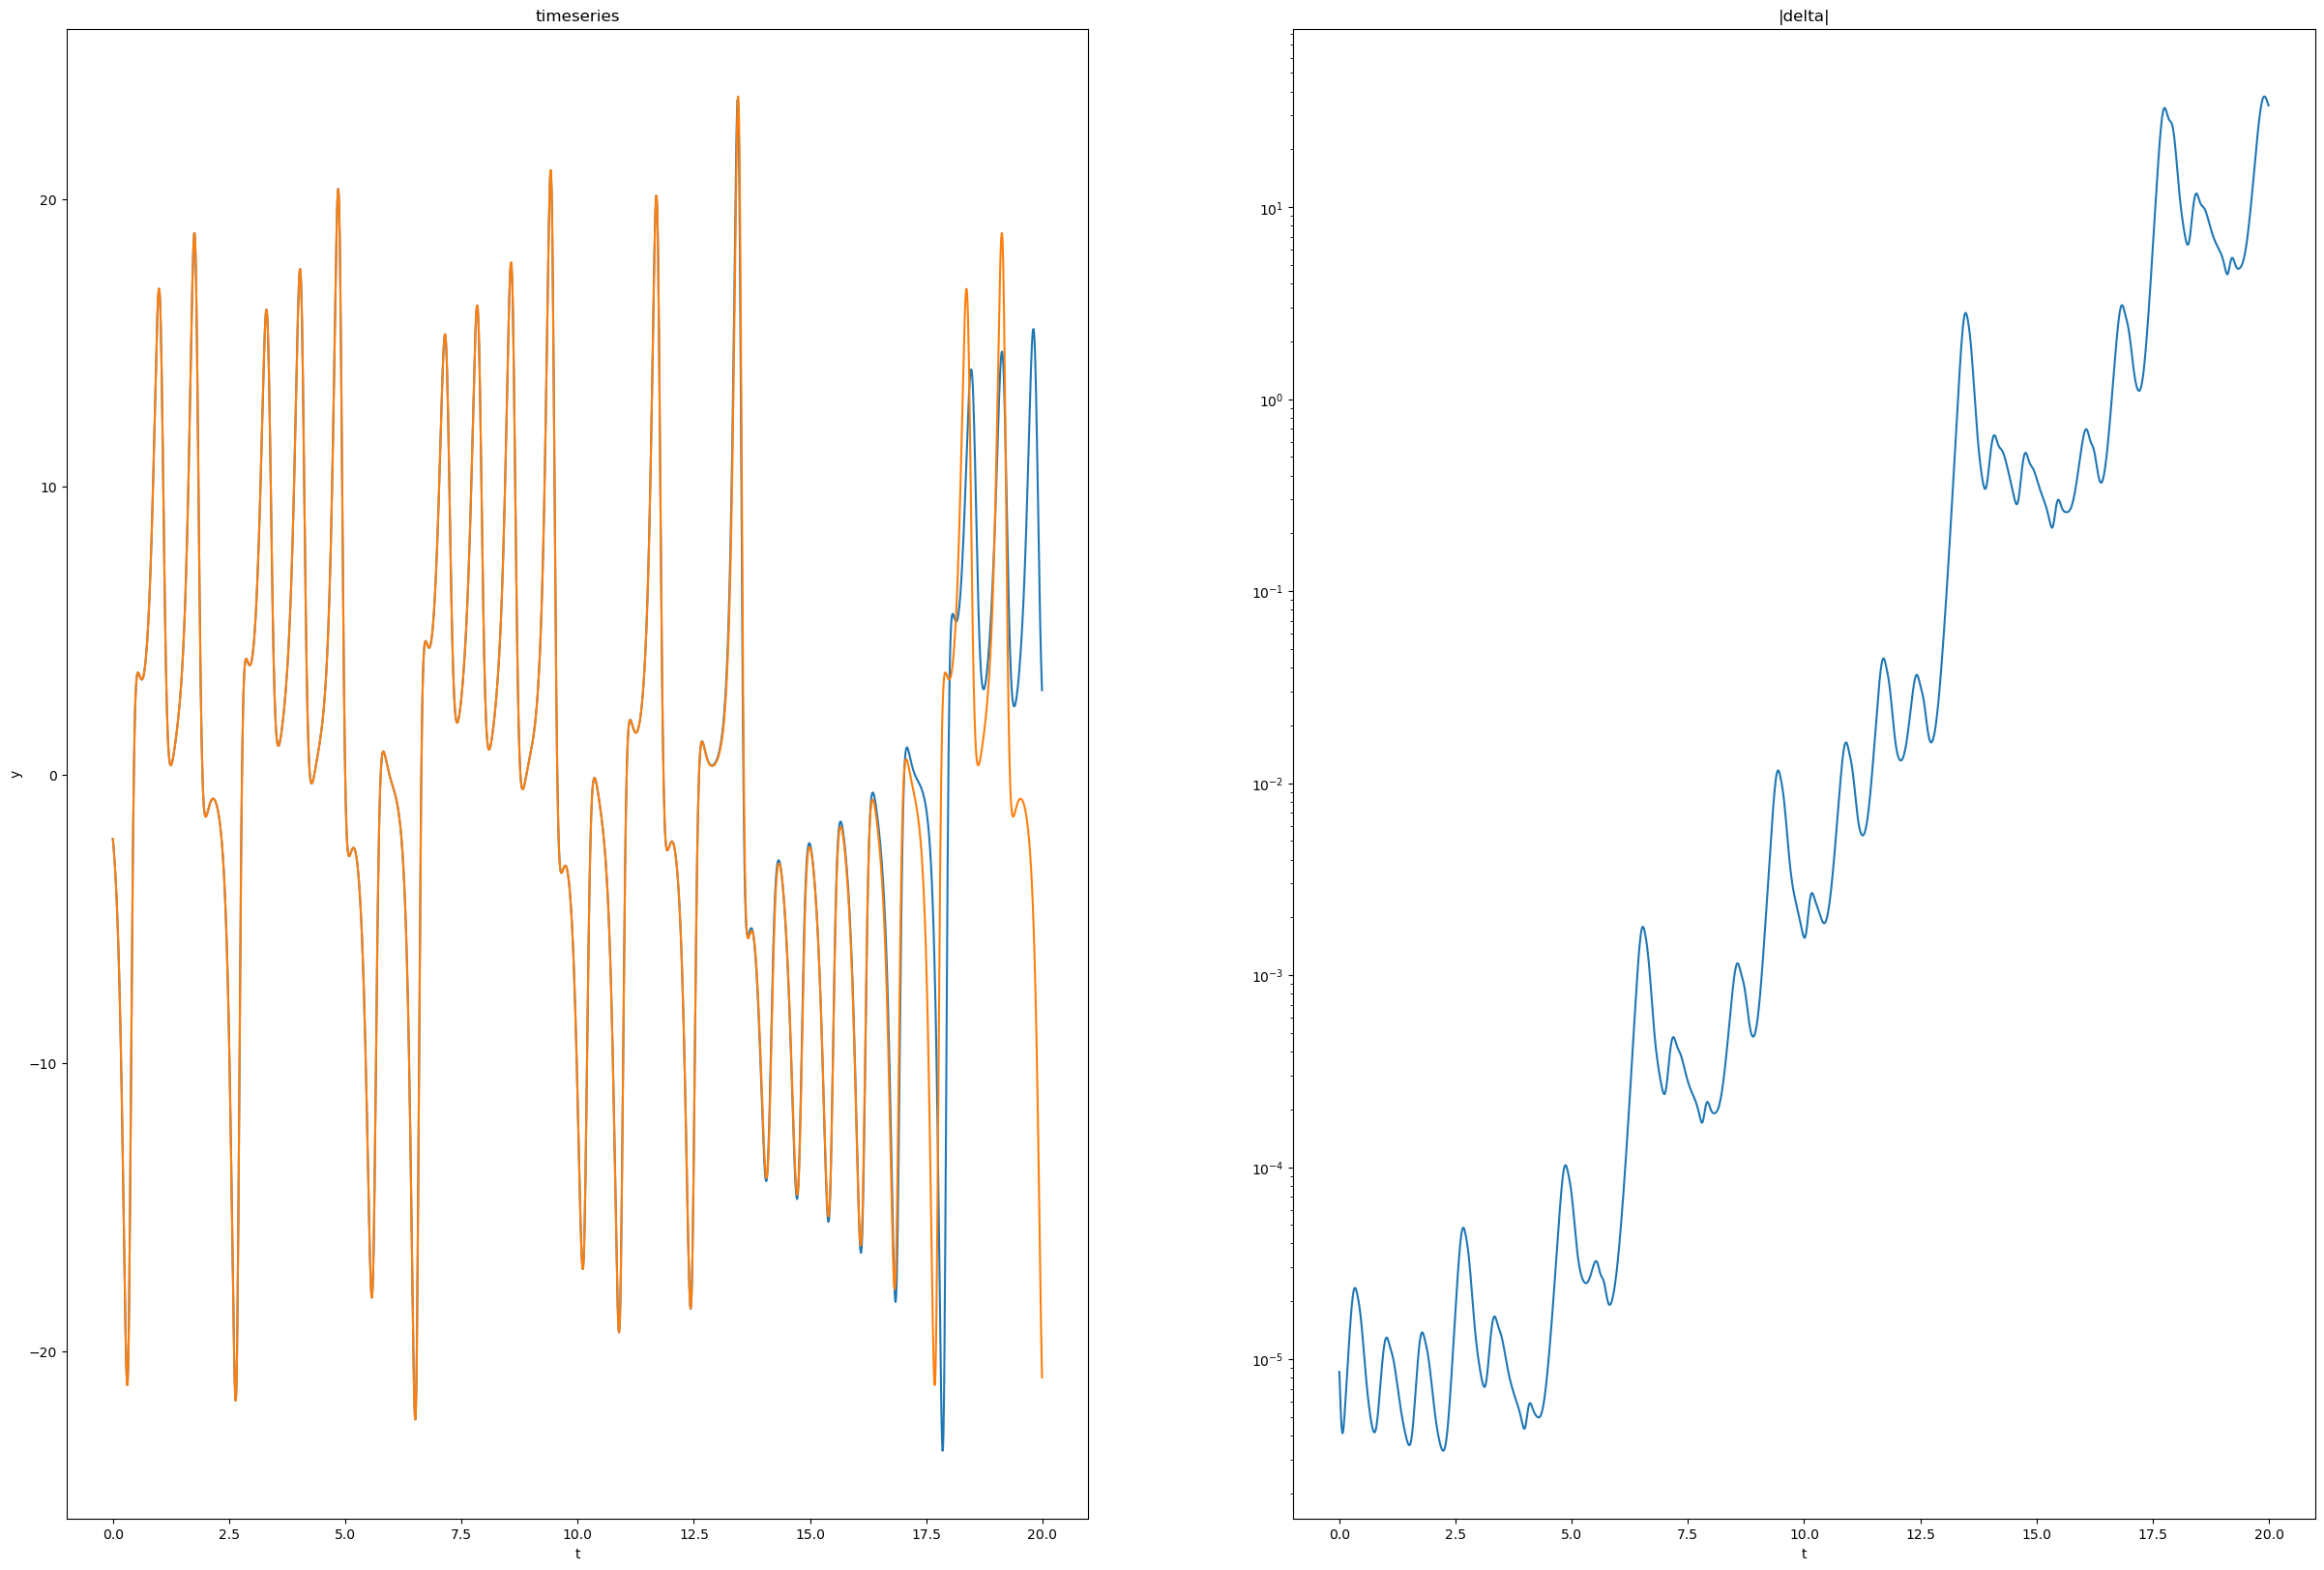

In [5]:
## divergence of neighbouring trajectories
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import matplotlib as mpl
# user define lorenz parameters (L63 values shown) and initial perturbation, delta
sig = 10  # (10)
b = 8/3   # (8/3)
r = 28    # (28)
delta = 10**(-5)
def lorenz(v, t):
    x = v[0]; y = v[1]; z = v[2]
    dxdt = sig*(y - x)
    dydt = r*x - y - x*z
    dzdt = x*y - b*z
    ddt = [dxdt, dydt, dzdt]
    return ddt
# integrate transient and discard
v0 = [0, 1, 0]
t = np.arange(0,20,0.01); v = odeint(lorenz, v0, t); v0 = v[-1,:]
# integrate from new initial condition on attractor
v  = odeint(lorenz, v0, t)
vpert = odeint(lorenz, v0+delta*np.random.randn(3), t)
diff = (np.sum((vpert-v)**2,1))**0.5
# plot
ax1 = plt.subplot(1,2,1)
plt.plot(t,v[:,1]), plt.plot(t,vpert[:,1])
plt.xlabel('t'); plt.ylabel('y'); plt.title('timeseries')
ax1 = plt.subplot(1,2,2)
plt.plot(t,diff)
plt.xlabel('t'); plt.title('|delta|'); plt.yscale('log')


$ $In numerical studies of the Lorenz attractor, one finds that $||{\bf \delta}(t)|| \sim ||{\bf \delta_0}|| e^{\lambda t}$, where $\lambda \simeq 0.9$. 

$ $We saw that if we plot $\ln ||{\bf \delta}(t)||$ versus $t$, we find a curve that is close to a straight line with a positive slope $\lambda$.

<div>
<img src="figures/fig6_2_5.png" width="600"/>
</div>


The curve is never straight, but has wiggles since the strength of exponential divergence varies somewhat along the attractor.

The exponential divergence must stop when the separation is comparable to the size of the attractor - the trajectories cannot get any further apart! (curve saturates for large $t$)

The slope $\lambda$ is often called the *Lyapunov exponent*. An $n$-dimensional system actually has $n$ Lyapunov exponents - we have found the largest.




<div>
<img src="figures/6_hurricanes.png" width="1200"/>
</div>



$ $Suppose we measure the initial conditions of an experimental system very accurately. Let there be some error $||\delta_0||$ between our estimate and the true initial state. After a time $t$ the discrepancy grows to $||\delta(t)|| \sim ||\delta_0|| e^{\lambda t}$. 

Let $a$ be a measure of our tolerance. Then our prediction becomes intolerable when $||\delta(t)|| \geq a$, i.e. after a time

$$ t_{horizon} \sim O \left({1 \over \lambda} \ln {a \over ||\delta||} \right) $$

$ $The logarithmic dependence on $||\delta_0||$ is what hurts ... 

#### Example

$ $Suppose $a = 10^{-3}$, $||\delta_0|| = 10^{-7}$.

$$ \Rightarrow t_{horizon} = {4 \ln 10 \over \lambda} $$



$ $If we improve the initial error to $||\delta_0|| = 10^{-13}$,

$$ \Rightarrow t_{horizon} = {10 \ln 10 \over \lambda} $$

i.e. only 10/4 = 2.5 times longer!

More on Lyapunov exponents and predictability with Myles in Lecture 11.

## Defining Chaos

It is hard to define chaos! But almost everyone would agree on the three properties used in the following working definition:

Chaos is *aperiodic long-term behaviour* in a *deterministic* system that exhibits *sensitive dependence* on *initial conditions*



$ $1. *Aperiodic long-term behaviour* means that there are trajectories which do not settle down to fixed points, periodic or quasi-periodic orbits as $t \rightarrow \infty$

$ $2. *Deterministic* means that the system has no random or noisy inputs or parameters. Irregular behaviour arises solely from the system's nonlinearity.

$ $3. *Sensitive dependence on initial conditions* means that nearby trajectories diverge exponentially fast, i.e. the system has at least one positive Lyapunov exponent. Or as Lorenz put it 'Chaos: When the present determines the future, but the approximate present does not approximately determine the future.'.



N.b Chaos is not just a fancy word for instability. \
E.g. $\dot{x} = x$ is deterministic and shows exponential separation of nearby trajectories. But it is not chaotic.

Trajectories are repelled to infinity, and never return. Hence infinity is *a fixed point* of the system, and requirement 1. above specifically excludes fixed points!

#### Defining 'attractor'

The term *attractor* is also difficult to define in a rigorous way. \
$\bullet$ a set of points to which all neighbouring trajectories converge. e.gs include stable fixed points and stable limit cycles

More precisely:
An attractor is a closed set $A$ with the following properties\

$\bullet$ $A$ is an *invariant set*: any trajectory ${\bf x}(t)$ that starts in $A$ stays in $A$ for all time.

$\bullet$ $A$ *attracts an open set of initial conditions*: there is an open set $U$ containing $A$ such that if ${\bf x}(0) \in U$, then the distance from ${\bf x}(t)$ to $A$ tends to zero as $t \rightarrow \infty$. Hence $A$ attracts all trajectories that start sufficiently close to it. The largest such $U$ is called the *basin of attraction* of $A$.

$\bullet$ $A$ is *minimal*: there is no proper subset of $A$ that satisfies conditions 1. and 2.





####  Example

Consider the system:

$ \dot{x}  =   \mu x - x^3$  

$ \dot{y}  =  -y$

Let $I$ denote the interval $-1 \leq x \leq 1, y=0$.

Is $I$ an attractor?

<div>
<img src="figures/fig6_2_7.png" width="600"/>
</div>



So, $I$ is an invariant set (condition 1.). Also, $I$ attracts an open set of initial conditions - it attracts *all* trajectories in the $xy$-plane. But $I$ is *not* an attractor because it is not minimal. The stable fixed points $(\pm1,0)$ are proper subsets of $I$ that also satisfy conditions 1. and 2. These points are the *only* attractors for the system. 

#### Defining 'strange attractor'


A *strange attractor* is an attractor that exhibits *sensitive dependence on initial conditions*.

Strange attractors were originally called strange because they are often (but not always...) fractal sets.

Nowadays, the dynamical property of sensitive dependence on initial conditions is considered more important than the geometric property.\
The terms “chaotic attractor” and “fractal attractor” are used when one wishes to emphasize one or other of these aspects.


## The Lorenz Map

Nevertheless, there is order in the choas. Consider the following view of the Lorenz strange attractor...

<div>
<img src="figures/fig6_3_1.png" width="800"/>
</div>


Lorenz wrote that “the trajectory apparently leaves one spiral only after exceeding some critical distance from the centre... It therefore seems that some single feature of a given circuit should predict the same feature of the following circuit.”


$ $The feature he focused on was $z_n$, the $n$th local maximum of $z(t)$.

<div>
<img src="figures/fig6_3_2.png" width="800"/>
</div>




$ $Lorenz's idea is that $z_n$ should predict $z_{n+1}$. He checked this by numerical integration. The plot of $z_{n+1}$ vs $z_n$ appears to fall neatly on a curve. Hence *Lorenz was able to extract order from chaos!*

<div>
<img src="figures/fig6_3_3.png" width="600"/>
</div>


The function $z_{n+1} = f(z_n)$ is now called the *Lorenz Map*. \
The graph is not actually a curve - it does have *some* thickness so, strictly speaking, $f(z)$ is not a well-defined function.


## Exploring Parameter Space

$ $So far we have concentrated mainly on  the case $\sigma = 10, b = 8/3, r = 28$ as in Lorenz's original work published in 1963. 

Changing parameters is like a walk through the jungle! One finds many sorts of exotic behaviours, such as exotic limit cycles tied in knots, pairs of limit cycles linked through each other, intermittent chaos, noisy periodicity.....as well as strange attractors! In fact much remains to be discovered....



#### Example

Show that the Lorenz equations exhibit *transient chaos* for $r = 21$, with $\sigma = 10$ and $b = 8/3$ as usual. 


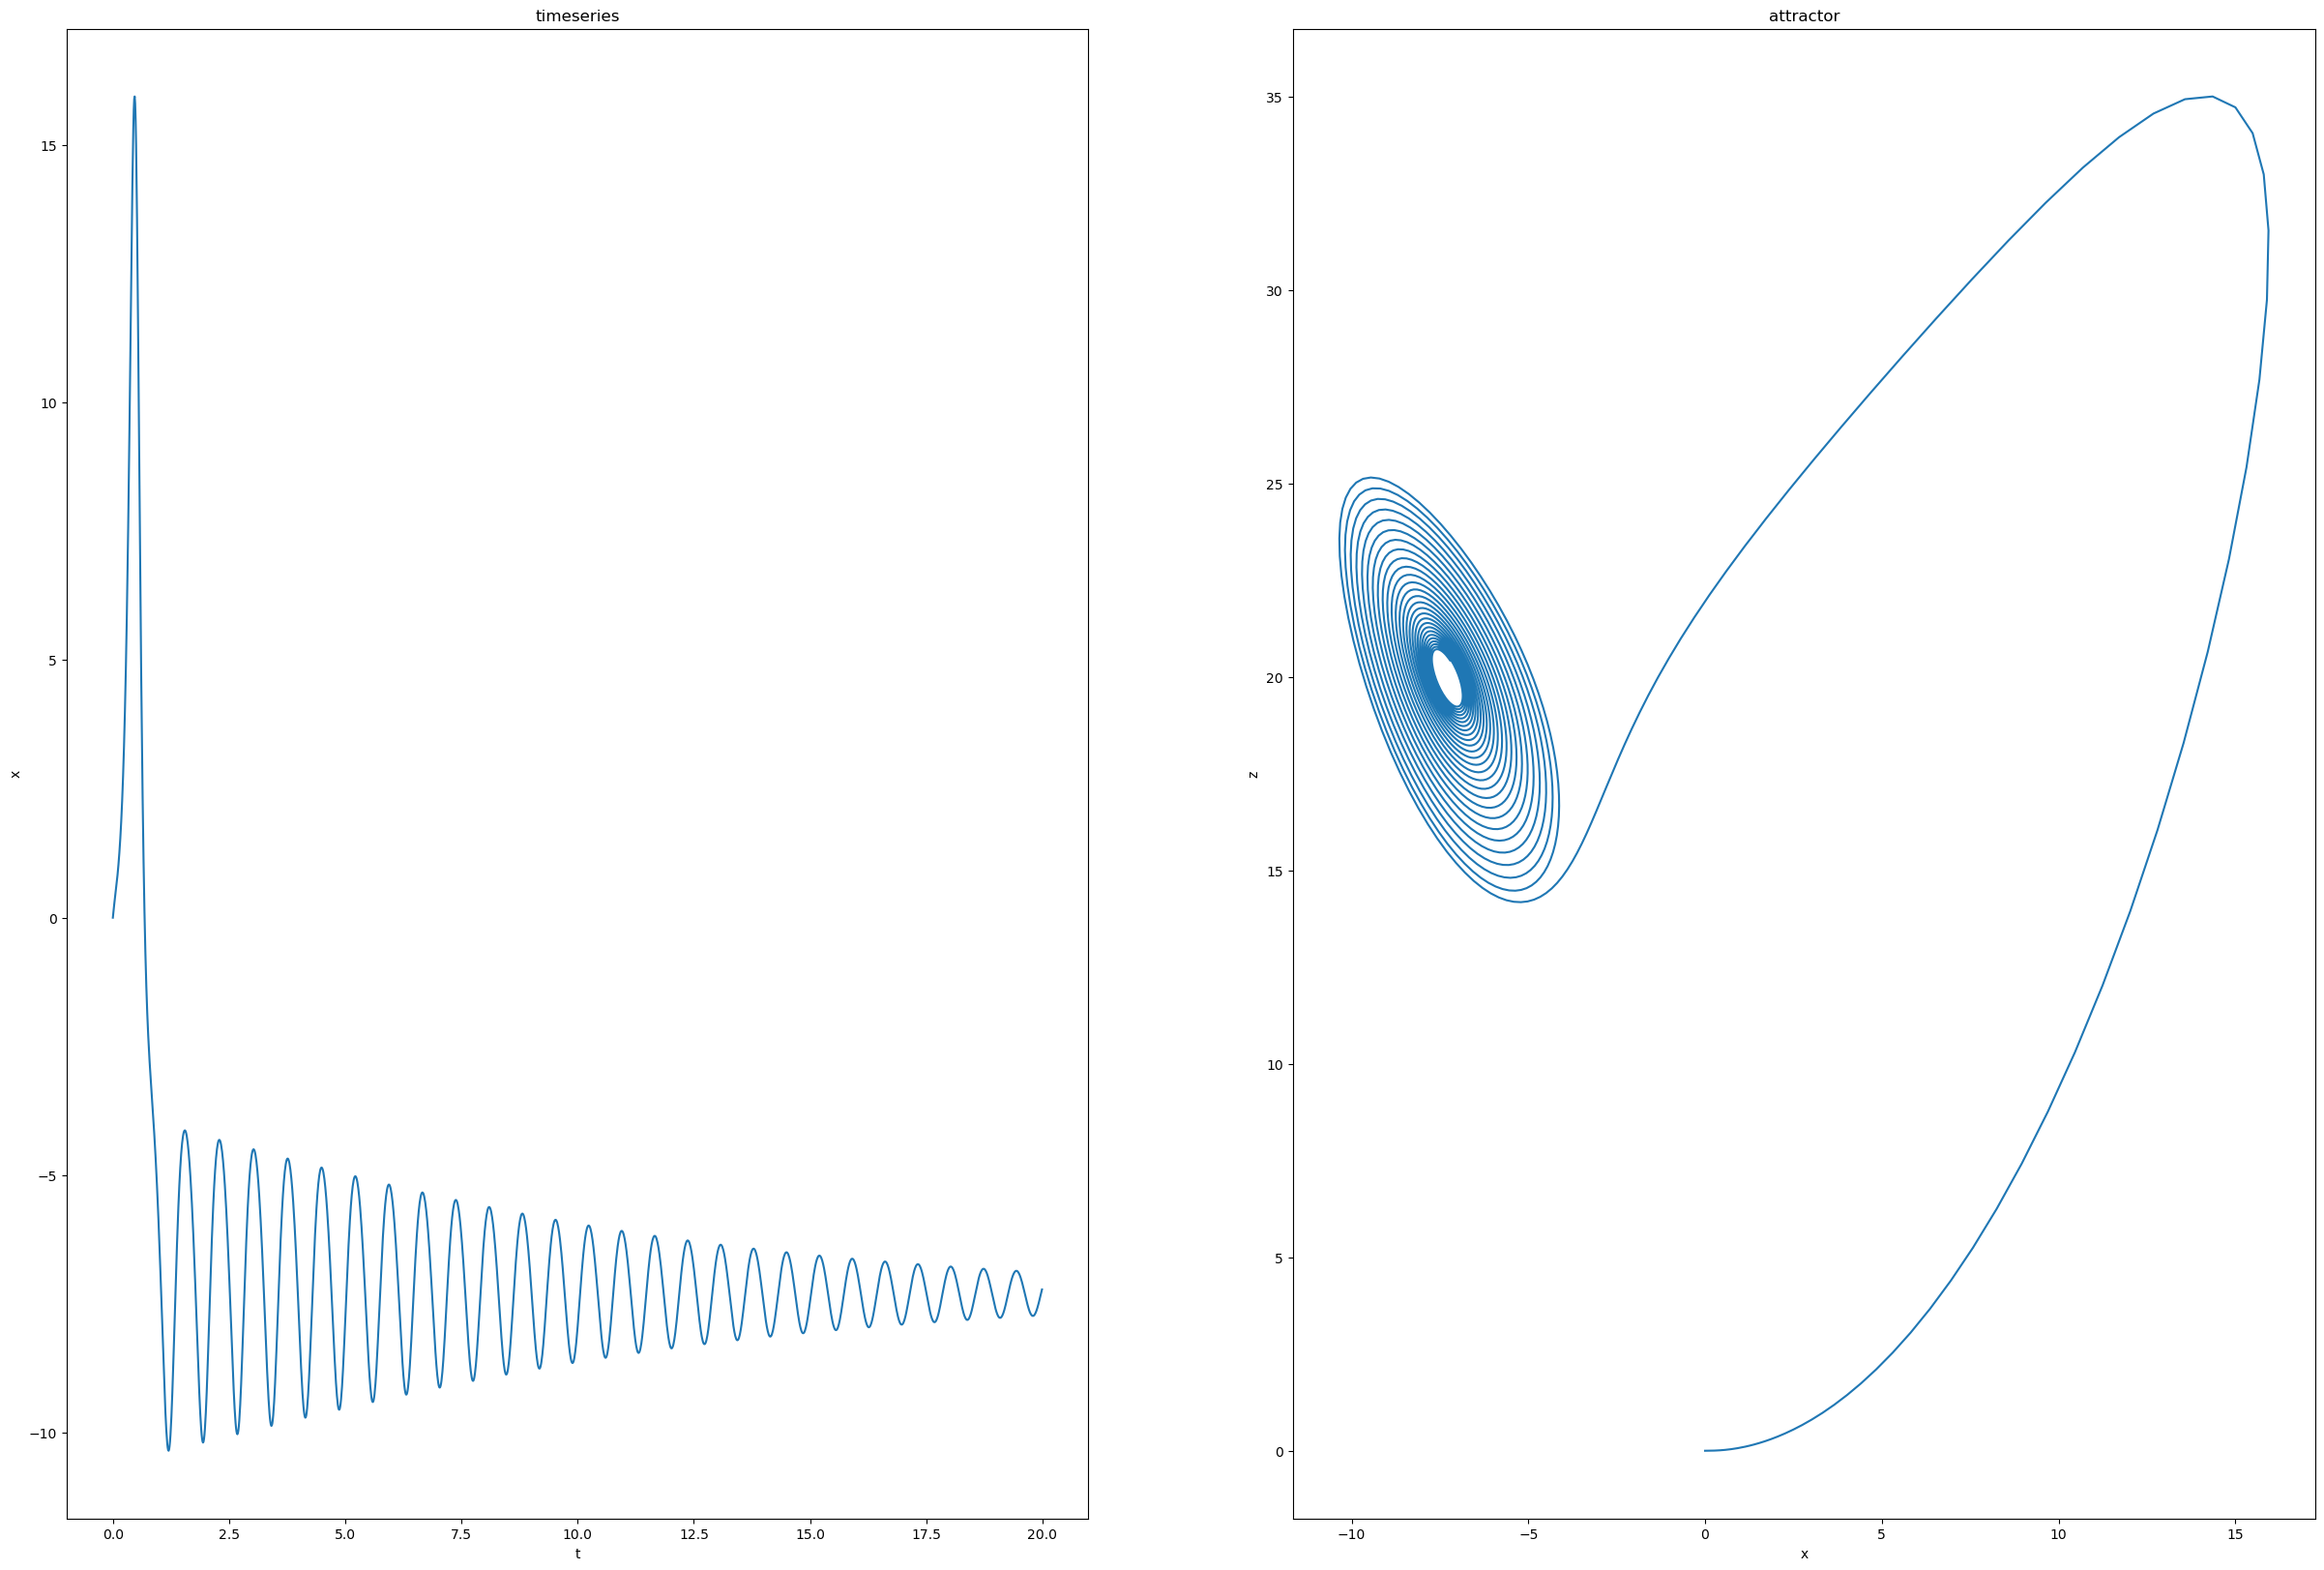

In [6]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import matplotlib as mpl

# define lorenz parameters. L63 values shown
sig = 10  # (10)
b = 8/3   # (8/3)
r = 21    # (28)

def lorenz(v, t):
    x = v[0]; y = v[1]; z = v[2]
    dxdt = sig*(y - x)
    dydt = r*x - y - x*z
    dzdt = x*y - b*z
    ddt = [dxdt, dydt, dzdt]
    return ddt

v0 = [0, 1, 0]
t = np.arange(0,20,0.01)
v = odeint(lorenz, v0, t)

ax1 = plt.subplot(1,2,1)
plt.plot(t,v[:,0])
plt.xlabel('t'); plt.ylabel('x'); plt.title('timeseries') 
ax2 = plt.subplot(1,2,2)
ax2.plot(v[:,0],v[:,2])
plt.xlabel('x'); plt.ylabel('z'); plt.title('attractor');

The solution exhibits *transient chaos*, in which the trajectory seems to be tracing a strange attractor, but eventually spirals towards $C^+$ or $C^-$...

<div>
<img src="figures/fig6_4_2.png" width="400"/>
</div>
<div>
<img src="figures/fig6_4_3.png" width="400"/>
</div>



$ $The long-term behaviour is not aperiodic - hence the dynamics are not chaotic. However, the dynamics do exhibit sensitive dependence on initial conditions - the trajectory could end up on either $C^+$ or $C^-$ - hence the system's behaviour is unpredictable. 

Transient chaos shows that a deterministic system can be unpredictable, even if its final states are very simple. This is familiar from everyday experience - many games of “chance” used in gambling are essentially demonstrations of transient chaos....e.g. a rolling dice...

You don’t need strange attractors to generate effectively random behaviour!

#### Example 

Describe the long time dynamics for very large values of r, with  $\sigma = 10$ and $b = 8/3$ as usual.

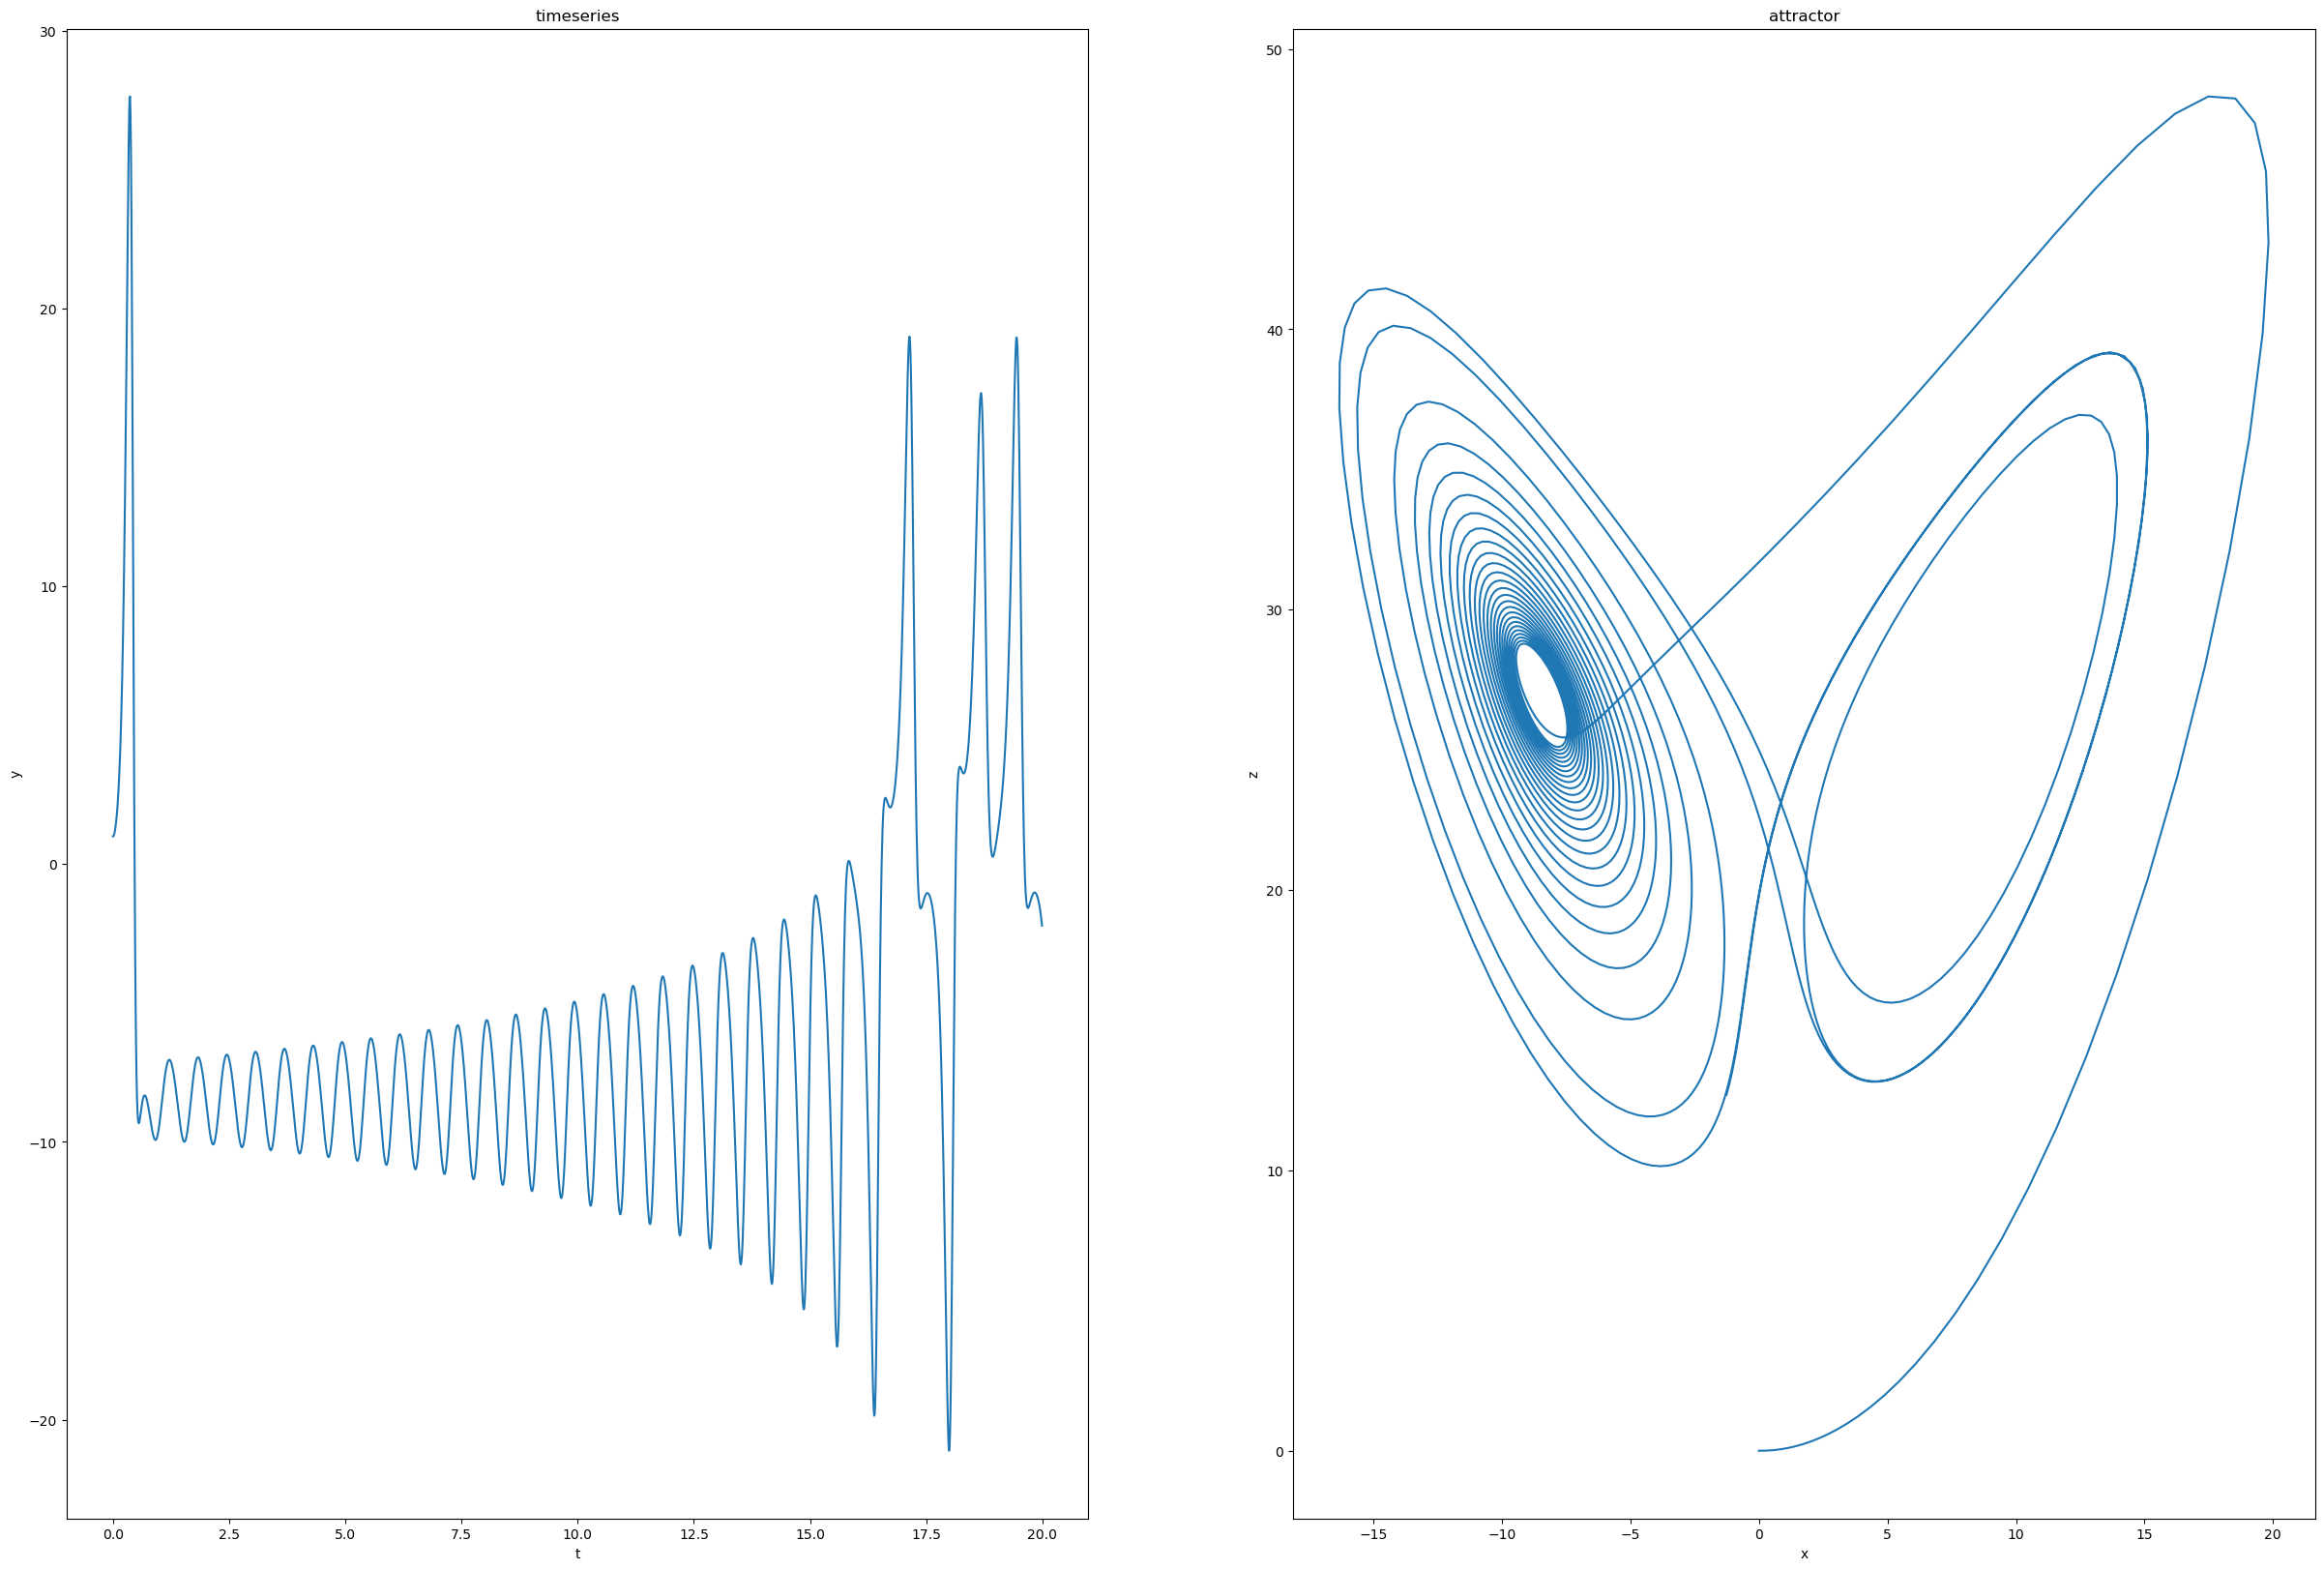

In [7]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import matplotlib as mpl

# define lorenz parameters. L63 values shown
sig = 10  # (10)
b = 8/3   # (8/3)
r = 28    # (28)

def lorenz(v, t):
    x = v[0]; y = v[1]; z = v[2]
    dxdt = sig*(y - x)
    dydt = r*x - y - x*z
    dzdt = x*y - b*z
    ddt = [dxdt, dydt, dzdt]
    return ddt

v0 = [0, 1, 0]
t = np.arange(0,20,0.01)
v = odeint(lorenz, v0, t)

ax1 = plt.subplot(1,2,1)
plt.plot(t,v[:,1])
plt.xlabel('t'); plt.ylabel('y'); plt.title('timeseries')
ax2 = plt.subplot(1,2,2)
ax2.plot(v[:,0],v[:,2])
plt.xlabel('x'); plt.ylabel('z'); plt.title('attractor');

$ $It turns out that for large $r$ the dynamics become simple again - the system has a global attracting limit cycle for $r > 313$. 

For $r = 350$, $\sigma = 10$, $b = 8/3$: 

<div>
<img src="figures/fig6_4_4.png" width="400"/>
</div>

<div>
<img src="figures/fig6_4_5.png" width="400"/>
</div>



<div>
<img src="figures/fig6_4_1.png" width="800"/>
</div>

## Postscript

The Lorenz equations were originally derived as a low-order truncated expansion, in the variable (r − 1), of the full Rayleigh-Bérnard convection problem in the weakly-nonlinear regime. In the parameter regimes that chaos occurs in the Lorenz model, the original approximations are no longer valid: (r − 1) = 27 is not a small parameter!

Nevertheless the Lorenz model is a fine example of the adage: all models are wrong, some models are useful (usually attributed to George Box).

The discovery of the strange attractor and the phenomenon of chaos has applicability to a wide range of problems and is widely regarded as one of the greatest discoveries in classical physics of the 20th century.